In [35]:
import tensorflow_datasets as tfds
import numpy as np
import tensorflow as tf
from collections import Counter



In [36]:
imdb,info = tfds.load('imdb_reviews',with_info=True, as_supervised=True)

In [37]:
info

tfds.core.DatasetInfo(
    name='imdb_reviews',
    full_name='imdb_reviews/plain_text/1.0.0',
    description="""
    Large Movie Review Dataset. This is a dataset for binary sentiment
    classification containing substantially more data than previous benchmark
    datasets. We provide a set of 25,000 highly polar movie reviews for training,
    and 25,000 for testing. There is additional unlabeled data for use as well.
    """,
    config_description="""
    Plain text
    """,
    homepage='http://ai.stanford.edu/~amaas/data/sentiment/',
    data_dir='C:\\Users\\PGCP-AI\\tensorflow_datasets\\imdb_reviews\\plain_text\\1.0.0',
    file_format=tfrecord,
    download_size=80.23 MiB,
    dataset_size=129.83 MiB,
    features=FeaturesDict({
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
        'text': Text(shape=(), dtype=string),
    }),
    supervised_keys=('text', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test':

In [38]:
imdb

{'train': <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>,
 'test': <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>,
 'unsupervised': <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>}

In [39]:
train_data,test_data=imdb['train'], imdb['test']

In [40]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [41]:
for d, l in train_data:
    print(d)
    print(l)
    break

tf.Tensor(b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.", shape=(), dtype=string)
tf.Tensor(0, shape=(), dtype=int64)


In [78]:
training_sentences = []
training_labels = []
testing_sentences = []
testing_labels = []

# 1. Loop through training data
for d, l in train_data:
    training_sentences.append(str(d.numpy()))
    training_labels.append(l.numpy())

# 2. Loop through test data (Double check this part!)
for d, l in test_data:
    testing_sentences.append(str(d.numpy()))  # Make sure this is 'd', not 'l'
    testing_labels.append(l.numpy())

In [79]:
training_sentences[0]

'b"This was an absolutely terrible movie. Don\'t be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie\'s ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor\'s like Christopher Walken\'s good name. I could barely sit through it."'

In [80]:
training_labels[0]

np.int64(0)

In [81]:
len(training_sentences), len(training_labels)

(25000, 25000)

In [82]:
len(testing_sentences), len(testing_labels)

(25000, 25000)

In [83]:
type(training_labels)

list

In [84]:
training_labels = np.array(training_labels)
testing_labels = np.array(testing_labels)


In [85]:
# testing_labels = np.array(testing_labels)

In [86]:
Counter(testing_labels)

Counter({np.int64(1): 12500, np.int64(0): 12500})

## Preprocess the data

In [87]:

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [88]:

tokenizer = Tokenizer(num_words=10000)

In [89]:

tokenizer.fit_on_texts(training_sentences)

In [90]:
tokenizer.word_index

{'the': 1,
 'and': 2,
 'a': 3,
 'of': 4,
 'to': 5,
 'is': 6,
 'br': 7,
 'in': 8,
 'it': 9,
 'i': 10,
 'this': 11,
 'that': 12,
 'was': 13,
 'as': 14,
 'for': 15,
 'with': 16,
 'movie': 17,
 'but': 18,
 'film': 19,
 "'s": 20,
 'on': 21,
 'you': 22,
 'not': 23,
 'are': 24,
 'his': 25,
 'he': 26,
 'have': 27,
 'be': 28,
 'one': 29,
 'all': 30,
 'at': 31,
 'by': 32,
 'they': 33,
 'an': 34,
 'who': 35,
 'so': 36,
 'from': 37,
 'like': 38,
 'her': 39,
 "'t": 40,
 'or': 41,
 'just': 42,
 'there': 43,
 'about': 44,
 'out': 45,
 "'": 46,
 'has': 47,
 'if': 48,
 'some': 49,
 'what': 50,
 'good': 51,
 'more': 52,
 'very': 53,
 'when': 54,
 'she': 55,
 'up': 56,
 'can': 57,
 'b': 58,
 'time': 59,
 'no': 60,
 'even': 61,
 'my': 62,
 'would': 63,
 'which': 64,
 'story': 65,
 'only': 66,
 'really': 67,
 'see': 68,
 'their': 69,
 'had': 70,
 'were': 71,
 'me': 72,
 'well': 73,
 'we': 74,
 'than': 75,
 'much': 76,
 'been': 77,
 'get': 78,
 'bad': 79,
 'will': 80,
 'people': 81,
 'do': 82,
 'also': 83,


In [91]:
sequences = tokenizer.texts_to_sequences(training_sentences)
padded = pad_sequences(sequences,maxlen=500,truncating="post",padding="post")

In [92]:
padded.shape

(25000, 500)

In [93]:
padded[0]

array([  58,   11,   13,   34,  438,  399,   17,  173,   28,    8,   32,
       1377, 3400,   41,  495,  196,   24,   87,  155,   18,   11,  210,
        339,   28,   69,  247,  212,    8,  485,   61,   69,   87,  115,
         98,   23, 5739,   11, 3316,  656,  776,   11,   17,    6,   34,
        405, 8227,  177, 2476,  425,    1,   91, 1252,  139,   71,  148,
         54,    1, 7524,   71,  228,   69, 2961,   15, 2879, 1505, 4997,
          2,   39, 3946,  118, 1607,   16, 3400,   13,  162,   18,    3,
       1252,  926, 7985,    8,    3,   17,   12,   13, 4199,    4,  101,
        147, 1236,   10,  239,  691,   12,   43,   24,  100,   38,   11,
       7231,   38, 1377,   51,  408,   10,   98, 1213,  873,  144,    9,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [94]:
testing_sequences = tokenizer.texts_to_sequences(testing_sentences)
testing_padded = pad_sequences(testing_sequences,maxlen=500,truncating="post",padding="post")

In [95]:
testing_padded.shape

(25000, 500)

## Simple RNN Model

In [96]:

from keras.models import Sequential
from keras.layers import SimpleRNN, LSTM, Dense, Embedding, Bidirectional
from keras.layers import LSTM, GRU

In [97]:
model_rnn = Sequential([
    Embedding(10000, 50, input_length=500),
    SimpleRNN(32),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")])

C:\Users\PGCP-AI\AppData\Local\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [98]:
model_rnn.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

In [106]:
!pip install matplotlib

In [107]:
history_rnn = model_rnn.fit(padded, training_labels,epochs = 10, validation_data=(testing_padded,testing_labels))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 108s 138ms/step - accuracy: 0.5366 - loss: 0.6580 - val_accuracy: 0.5004 - val_loss: 0.7235
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 102s 131ms/step - accuracy: 0.5342 - loss: 0.6618 - val_accuracy: 0.5037 - val_loss: 0.7312
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 101s 129ms/step - accuracy: 0.5289 - loss: 0.6561 - val_accuracy: 0.5011 - val_loss: 0.7364
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 101s 129ms/step - accuracy: 0.5274 - loss: 0.6658 - val_accuracy: 0.5058 - val_loss: 0.7005
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 106s 135ms/step - accuracy: 0.5400 - loss: 0.6649 - val_accuracy: 0.5054 - val_loss: 0.7106
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 110s 141ms/step - accuracy: 0.5388 - loss: 0.6536 - val_accuracy: 0.5052 - val_loss: 0.7316
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 111s 142ms/step - accuracy: 0.5347 - loss: 0.6478 - val_accuracy: 0.4980 - val_loss: 0.7620
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 111s 141ms/step - accuracy: 0.5350 -

In [110]:
import sys
!{sys.executable} -m pip install matplotlib
import matplotlib.pyplot as plt

  Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ------------- -------------------------- 0.8/2.4 MB 3.7 MB/s eta 0:00:01
   ---------------------- ----------------- 1.3/2.4 MB 2.7 MB/s eta 0:00:01
   ---------------------- ----------------- 1.3/2.4 MB 2.7 MB/s eta 0:00:01
   ------------------------------- -------- 1.8/2.4 MB 2.1 MB/s eta 0:00:01
   ----------------------------------- ---- 2.1/2.4 MB 2.1 MB/s eta 0:00:01
   -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


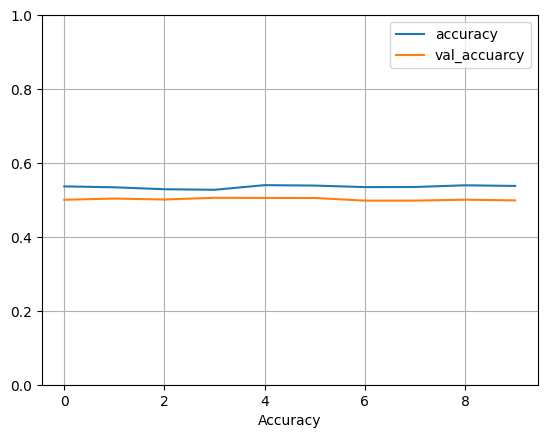

In [114]:
plt.xlabel("Accuracy")
plt.ylim(0,1)
plt.grid()
plt.plot(history_rnn.history["accuracy"],label= "accuracy")
plt.plot(history_rnn.history["val_accuracy"], label="val_accuarcy")
plt.legend()


## LSTM

In [115]:

model_lstm = Sequential([
    Embedding(10000, 50, input_length=500),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

C:\Users\PGCP-AI\AppData\Local\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [116]:

model_lstm.compile(loss='binary_crossentropy', optimizer='adam',
                   metrics=['accuracy'])

In [ ]:
history_lstm = model_lstm.fit(padded, training_labels, epochs=10,
                              validation_data = (testing_padded, testing_labels))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 185s 232ms/step - accuracy: 0.5008 - loss: 0.6928 - val_accuracy: 0.5059 - val_loss: 0.6917
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 183s 234ms/step - accuracy: 0.5129 - loss: 0.6886 - val_accuracy: 0.5051 - val_loss: 0.6932
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 176s 225ms/step - accuracy: 0.5242 - loss: 0.6716 - val_accuracy: 0.5111 - val_loss: 0.6972
Epoch 4/10
609/782 ━━━━━━━━━━━━━━━━━━━━ 28s 164ms/step - accuracy: 0.5280 - loss: 0.6537

## GRU

In [ ]:
plt.xlabel('Accuracy')
plt.ylim(0,1)
plt.grid()

plt.plot(history_lstm.history['accuracy'],label='accuracy')
plt.plot(history_lstm.history['val_accuracy'],label='val_accuracy')
plt.plot(history_lstm.history['loss'],label='loss')
plt.legend()

In [ ]:
model_GRU = Sequential([
    Embedding(10000, 50, input_length=500),
    GRU(32),
    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

In [ ]:
model_GRU.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history_GRU = model_GRU.fit(padded, training_labels, epochs = 10,
                            validation_data = (testing_padded, testing_labels))

In [ ]:
plt.xlabel('Accuracy')
plt.ylim(0,1)
plt.grid()

plt.plot(history_GRU.history['accuracy'],label='accuracy')
plt.plot(history_GRU.history['val_accuracy'],label='val_accuracy')
plt.plot(history_GRU.history['loss'],label='loss')
plt.legend()

In [ ]:
plt.title('Accuracy Comparison')
plt.plot(history.history['accuracy'], label='Simple RNN', color='r', marker='.')
plt.plot(history_lstm.history['accuracy'], label='LSTM', color='g', marker='.')
plt.plot(history_gru.history['accuracy'], label='GRU', color='b', marker='.')
plt.legend()